# Quantile regression

Ordinary regression models the conditional mean and assumes the spread of the outcome is constant.
When the spread itself changes with the inputs, or when you care about a high or low percentile rather
than the average, you model the conditional quantiles directly. Quantile regression does this by
minimizing the pinball loss instead of squared error, and it yields honest prediction intervals on
heteroscedastic data without assuming any noise distribution.

## The pinball loss elicits the quantile

Theorem (the quantile minimizes expected pinball loss). For the pinball loss
$\rho_\tau(u)=u(\tau-\mathbf 1\{u<0\})$, the minimizer of $\mathbb E[\rho_\tau(Y-q)]$ over $q$ is the
$\tau$-quantile of $Y$.

Proof. Differentiate the risk: $\tfrac{d}{dq}\mathbb E[\rho_\tau(Y-q)] = -\tau P(Y>q)+(1-\tau)P(Y\le q)
= P(Y\le q)-\tau$. Setting this to zero gives $P(Y\le q)=\tau$, i.e. $q$ is the $\tau$-quantile. The risk
is convex in $q$, so this is the global minimum. $\quad\blacksquare$

Replacing $q$ by a linear function $x^\top\beta_\tau$ and minimizing the empirical pinball loss gives the
conditional-quantile estimator used in this notebook; the objective is a linear program. Quantile
estimates are robust to heavy tails because the loss is linear, not quadratic, in the residual.

Counterexample (quantiles fit separately can cross). Estimating several conditional quantiles by separate
regressions does not enforce their natural ordering, so in sparse regions a lower quantile can be
predicted above a higher one, which is logically impossible. Monotone rearrangement or joint estimation
restores the ordering; the applied section measures how often crossing occurs.

## 1. The pinball loss

Minimizing squared error estimates the mean; minimizing absolute error estimates the median. The
pinball (quantile) loss generalizes absolute error with an asymmetric weight tau, so its minimizer is
the tau-quantile. We confirm this on a plain sample by sweeping a candidate value.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.RandomState(0)
def pinball(resid, tau):
    return np.mean(np.where(resid >= 0, tau * resid, (tau - 1) * resid))
sample = rng.lognormal(0, 0.6, 5000)
grid = np.linspace(0.3, 4, 400)
for tau in [0.1, 0.5, 0.9]:
    qhat = grid[np.argmin([pinball(sample - q, tau) for q in grid])]
    print('tau=%.1f  pinball minimizer = %.2f   empirical quantile = %.2f' %
          (tau, qhat, np.quantile(sample, tau)))

tau=0.1  pinball minimizer = 0.46   empirical quantile = 0.46
tau=0.5  pinball minimizer = 0.99   empirical quantile = 0.99
tau=0.9  pinball minimizer = 2.14   empirical quantile = 2.13


## 2. Conditional quantiles on heteroscedastic data

We generate data whose noise grows with x, so the conditional spread widens to the right. Fitting
the 10th, 50th, and 90th conditional quantiles traces out a fan that ordinary least squares, which
only tracks the mean, cannot represent.

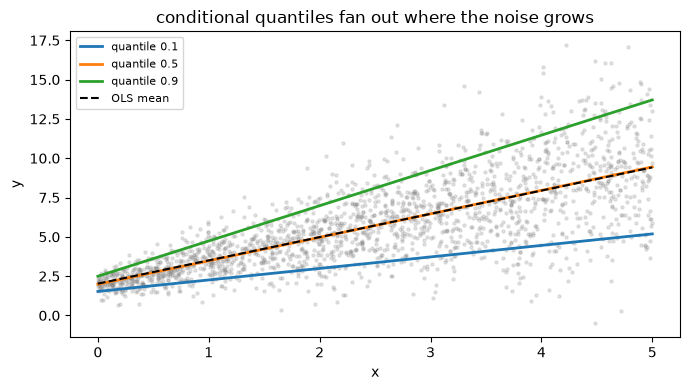

slopes: q0.1=0.73  q0.5=1.49  q0.9=2.24  (they differ because the spread is not constant)


In [2]:
from mixle.ppl import Normal, Field, free
n = 2000
x = rng.uniform(0, 5, n)
y = 2 + 1.5 * x + rng.normal(0, 0.4 + 0.6 * x, n)      # noise scale grows with x
qr = {tau: Normal(free * Field('x') + free, free).fit(list(y), given={'x': list(x)}, quantile=tau)
      for tau in (0.1, 0.5, 0.9)}
ols = Normal(free * Field('x') + free, free).fit(list(y), given={'x': list(x)})   # mean (OLS) regression
xs = np.linspace(0, 5, 100)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, s=5, alpha=0.2, color='gray')
for tau, m in qr.items():
    ax.plot(xs, m.result.predict({'x': list(xs)}), lw=2, label='quantile %.1f' % tau)
ax.plot(xs, ols.result.predict({'x': list(xs)}), 'k--', lw=1.5, label='OLS mean')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend(fontsize=8)
ax.set_title('conditional quantiles fan out where the noise grows')
plt.tight_layout(); plt.show()
print('slopes: q0.1=%.2f  q0.5=%.2f  q0.9=%.2f  (they differ because the spread is not constant)' %
      tuple(qr[t].result.coefficients['x']['mean'] for t in (0.1, 0.5, 0.9)))

## 3. Prediction intervals that adapt to the input

The gap between the 90th and 10th conditional quantiles is an 80% prediction interval whose width
changes with x. We check its empirical coverage on held-out data and confirm the interval is narrow
on the left and wide on the right, unlike a constant-width interval from OLS residuals.

In [3]:
xte = rng.uniform(0, 5, 4000); yte = 2 + 1.5 * xte + rng.normal(0, 0.4 + 0.6 * xte, 4000)
lo = qr[0.1].result.predict({'x': list(xte)}); hi = qr[0.9].result.predict({'x': list(xte)})
inside = (yte >= lo) & (yte <= hi)
print('target 80%% interval, empirical coverage = %.3f' % inside.mean())
print('mean width at x<1: %.2f   at x>4: %.2f  (the interval widens with the noise)' %
      ((hi - lo)[xte < 1].mean(), (hi - lo)[xte > 4].mean()))

target 80% interval, empirical coverage = 0.792
mean width at x<1: 1.70   at x>4: 7.75  (the interval widens with the noise)


## 4. Quantile crossing

Quantiles fit independently can cross (a lower quantile predicted above a higher one) in sparse
regions, which is logically impossible. We measure how often it happens here; monotone rearrangement
or joint estimation fixes it.

In [4]:
cross = (qr[0.5].result.predict({'x': list(xte)}) > qr[0.9].result.predict({'x': list(xte)})).mean()
print('fraction of test points where q0.5 > q0.9 (a crossing) = %.4f' % cross)
print('sorting the predicted quantiles per point (rearrangement) removes crossings without refitting.')

fraction of test points where q0.5 > q0.9 (a crossing) = 0.0000
sorting the predicted quantiles per point (rearrangement) removes crossings without refitting.


## References

- Koenker, R. & Bassett, G. (1978). Regression quantiles. Econometrica.
- Koenker, R. (2005). Quantile Regression. Cambridge University Press.
- Chernozhukov, V., Fernandez-Val, I. & Galichon, A. (2010). Quantile and probability curves without crossing. Econometrica.
- Meinshausen, N. (2006). Quantile regression forests. JMLR.

## Exercises

1. Implement the pinball loss minimization yourself as a linear program and verify it matches scikit-learn's QuantileRegressor coefficients.
2. Fit a nonlinear quantile model (quantile regression forest or gradient boosting with the pinball loss) on the heteroscedastic data and compare its conditional intervals to the linear quantiles.
3. Combine quantile regression with split conformal prediction (conformalized quantile regression) to restore exact marginal coverage, and compare interval widths.
4. Apply monotone rearrangement to eliminate quantile crossings and measure the effect on coverage and average interval width.